# 📘 File 05 — Geography and German Language Level Analysis

## 🔹 1. Loading Data

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
import plotly.express as px
import re

deals_df = pd.read_excel("Deals_clean.xlsx")

## #️⃣ 2. Adding Revenue and AOV Calculation

In [2]:
MAIN_PRODUCTS = ["Digital Marketing", "UX/UI Design", "Web Developer"]

def calc_revenue(row):
    if row["Stage"] != "Payment Done":
        return 0
    if row["Product"] not in MAIN_PRODUCTS:
        return 0

    initial = row["Initial Amount Paid"]
    offer = row["Offer Total Amount"]
    cd = row["Course duration"]
    ms = row["Months of study"]

    if pd.isna(initial):
        return 0
    if pd.isna(offer):
        return initial
    if pd.isna(cd) or cd <= 1:
        return initial
    if pd.isna(ms) or ms <= 1:
        return initial

    monthly_payment = (offer - initial) / (cd - 1)
    revenue = initial + monthly_payment * (ms - 1)

    return min(revenue, offer)

deals_df["Revenue"] = deals_df.apply(calc_revenue, axis=1)
deals_df["AOV"] = deals_df["Revenue"] / deals_df["Months of study"].replace(0, 1)
deals_df["Is_won"] = deals_df["Stage"] == "Payment Done"

## #️⃣ 3. City Analysis

### 🧹 Cleaning City Names

In [3]:
import re

def clean_city(city):
    if pd.isna(city):
        return None
    
    city = str(city).strip()

    # Remove garbage values
    if re.search(r"\d", city):
        return None
    if "," in city:
        return None
    if "str" in city.lower():
        return None
    if "straße" in city.lower():
        return None

    if city in ["Unknown", "#REF!", "", "-", None]:
        return None

    # Foreign cities
    foreign = [
        "Warszawa", "Gdańsk", "Gdynia", "Słupsk", "Śrem",
        "London", "Moscow", "Saint Petersburg", "Nizhny Novgorod",
        "Novorossiysk", "Cheremkhovo", "Kharkiv", "Kamenskoe",
        "Novi Sad", "Ajman", "Taraz", "Semej", "Almaty", "Astana",
        "Bat yam", "Belgrade", "Namur", "Zoetermeer", "Rotterdam",
        "Dubai", "Baku", "Phuket"
    ]
    if city in foreign:
        return None

    # Austria
    austria = ["Wien", "Linz", "Graz", "Salzburg", "Villach"]
    if city in austria:
        return None

    return city

deals_df["City_clean"] = deals_df["City"].apply(clean_city)
deals_df = deals_df[deals_df["City_clean"].notna()]

### 📊 City Performance

In [4]:
city_perf = (
    deals_df.groupby("City_clean")
    .agg(
        Deals_count=("Id", "count"),
        Deals_won=("Is_won", "sum"),
        Revenue=("Revenue", "sum")
    )
    .reset_index()
)

city_perf["CR"] = city_perf["Deals_won"] / city_perf["Deals_count"]
city_perf["AOV"] = city_perf["Revenue"] / city_perf["Deals_won"].replace(0, np.nan)

city_perf = city_perf.sort_values("Deals_won", ascending=False).round(2)
city_perf.head(10)

,City_clean,Deals_count,Deals_won,Revenue,CR,AOV
82,Berlin,182,78,373430.0,0.43,4787.56
505,München,74,27,86155.0,0.36,3190.93
277,Hamburg,62,22,84025.0,0.35,3819.32
416,Leipzig,45,18,76725.0,0.40,4262.50
392,Köln,25,9,54630.0,0.36,6070.00
551,Nürnberg,45,9,37600.0,0.20,4177.78
161,Dresden,28,9,28350.0,0.32,3150.00
168,Düsseldorf,33,7,38040.0,0.21,5434.29
213,Frankfurt,27,7,24200.0,0.26,3457.14
557,Oberhausen,9,7,39895.0,0.78,5699.29


## 🗺️ Map of Successful Deals by City

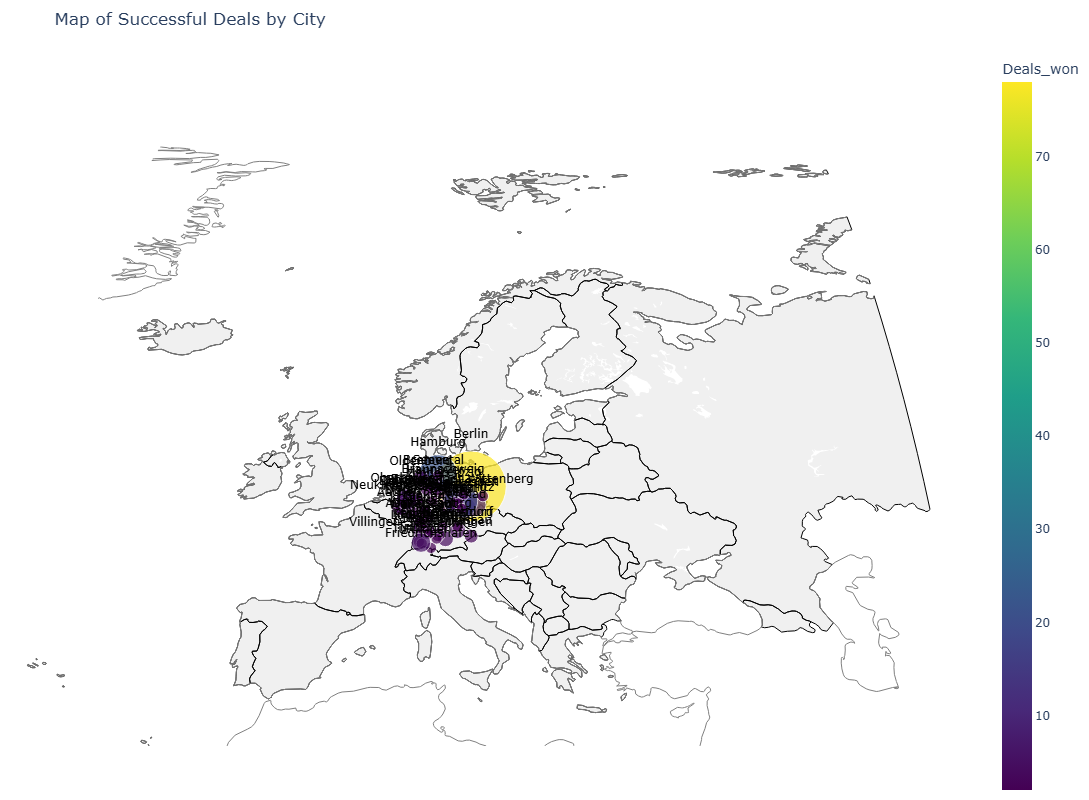

In [6]:
import plotly.express as px
import pandas as pd

# 1. Deals by city
gdf = (
    deals_df.groupby("City")
    .agg(Deals_won=("Is_won", "sum"))
    .reset_index()
)

# 2. Coordinates
coords_df = pd.read_csv("city_coords_full.csv")

# 3. Normalize city names
def normalize_city(city):
    if pd.isna(city):
        return "UnknownCity"
    city = str(city).strip()
    city = city.replace("ä","a").replace("ö","o").replace("ü","u")
    city = city.replace("Ä","A").replace("Ö","O").replace("Ü","U")
    city = city.replace("ß","ss")
    return city

gdf["City_norm"] = gdf["City"].apply(normalize_city)
coords_df["City_norm"] = coords_df["City_norm"].apply(normalize_city)

gdf = gdf.merge(coords_df, on="City_norm", how="inner")

gdf["geometry"] = gpd.points_from_xy(gdf["lon"], gdf["lat"])
gdf = gpd.GeoDataFrame(gdf, geometry="geometry")

df = pd.DataFrame({
    "City": gdf["City"],
    "lon": gdf["lon"],
    "lat": gdf["lat"],
    "Deals_won": gdf["Deals_won"]
})

df = gdf[gdf["Deals_won"] > 1].copy()

fig = px.scatter_geo(
    df,
    lon="lon",
    lat="lat",
    hover_name="City",
    text="City",
    size="Deals_won",
    color="Deals_won",
    size_max=50,
    color_continuous_scale="Viridis",
    projection="natural earth",
    title="Map of Successful Deals by City"
)

fig.update_traces(
    textposition="top center",
    textfont=dict(size=12, color="black")
)

fig.update_geos(
    resolution=50,
    scope="europe",
    showcountries=True,
    countrycolor="black",
    showland=True,
    landcolor="#f0f0f0",
    showcoastlines=True,
    coastlinecolor="gray"
)

fig.update_layout(
    height=800,
    margin={"r":0,"t":50,"l":0,"b":0}
)

fig.show()

### 🎯 Insight
 ✔ Berlin — key market, high volume and revenue  
 ✔ München, Hamburg — stable markets with strong AOV  
 ✔ Dortmund, Frankfurt — expensive products but low CR  
 ✔ Düsseldorf — many leads but weak conversion → optimization point  

## 🔹 4. German Language Level Analysis

### ✅ Normalizing “Level of Deutsch”

In [7]:
def normalize_level(x):
    if pd.isna(x):
        return "Unknown"
    
    x = str(x).upper().strip()

    # Cyrillic → Latin
    x = (
        x.replace("А", "A")
         .replace("Б", "B")
         .replace("В", "B")
         .replace("С", "C")
         .replace("Я", "A")
         .replace("НЯ", "A0")
    )

    for ch in [" ", "(", ")", ",", ".", "_"]:
        x = x.replace(ch, "")

    found = re.findall(r"(A0|A1|A2|B1|B2|C1|C2)", x)
    if found:
        order = ["A0","A1","A2","B1","B2","C1","C2"]
        return sorted(found, key=lambda lvl: order.index(lvl))[-1]

    if "-" in x:
        parts = re.split(r"[-]", x)
        found = [p for p in parts if p in ["A0","A1","A2","B1","B2","C1","C2"]]
        if found:
            return found[-1]

    prefix = x[:2]
    if prefix in ["A0","A1","A2","B1","B2","C1","C2"]:
        return prefix

    return "Unknown"

deals_df["Level of Deutsch"] = deals_df["Level of Deutsch"].apply(normalize_level)
sorted(deals_df["Level of Deutsch"].unique())

['A0', 'A1', 'A2', 'B1', 'B2', 'C1', 'C2', 'Unknown']

### 📊 German Level Performance

In [8]:
lang_perf = (
    deals_df.groupby("Level of Deutsch")
    .agg(
        Deals_count=("Id", "count"),
        Deals_won=("Is_won", "sum"),
        Revenue=("Revenue", "sum")
    )
    .reset_index()
)

lang_perf["CR"] = lang_perf["Deals_won"] / lang_perf["Deals_count"]
lang_perf["AOV"] = lang_perf["Revenue"] / lang_perf["Deals_won"].replace(0, np.nan)

lang_perf = lang_perf[
    ~lang_perf["Level of Deutsch"].isin(["Unknown", "#REF!", "", None])
]

lang_perf = lang_perf.sort_values("CR", ascending=False).round(2)
lang_perf

,Level of Deutsch,Deals_count,Deals_won,Revenue,CR,AOV
0,A0,5,3,8600.0,0.60,2866.67
1,A1,18,9,47800.0,0.50,5311.11
6,C2,5,2,11000.0,0.40,5500.00
3,B1,638,234,1042005.0,0.37,4453.01
4,B2,195,61,313130.0,0.31,5133.28
5,C1,32,10,37580.0,0.31,3758.00
2,A2,100,31,177850.0,0.31,5737.10


## 🌍 German Level Geo‑Map

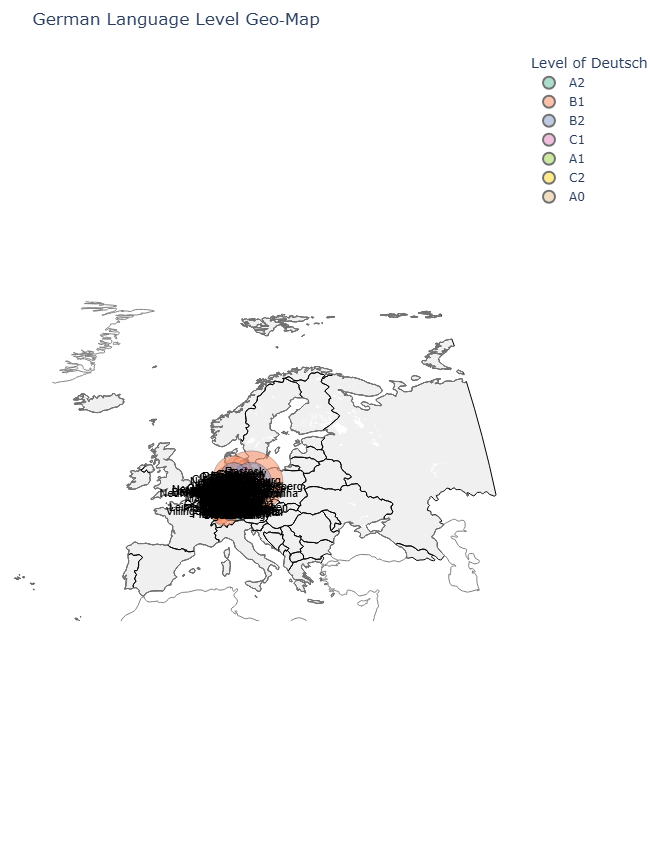

In [9]:
import pandas as pd
import plotly.express as px

def normalize_city(city):
    if pd.isna(city):
        return "UnknownCity"

    city = str(city).strip()

    city = city.replace("ä", "a").replace("ö", "o").replace("ü", "u")
    city = city.replace("Ä", "A").replace("Ö", "O").replace("Ü", "U")
    city = city.replace("ß", "ss")

    city = city.replace("é", "e").replace("è", "e").replace("ê", "e")
    city = city.replace("á", "a").replace("à", "a").replace("â", "a")
    city = city.replace("ó", "o").replace("ò", "o").replace("ô", "o")
    city = city.replace("ú", "u").replace("ù", "u").replace("û", "u")
    city = city.replace("í", "i").replace("ì", "i").replace("î", "i")

    city = city.replace("  ", " ")
    return city

deals_df["City_norm"] = deals_df["City"].apply(normalize_city)

coords_df = pd.read_csv("city_coords_full.csv")
coords_df["City_norm"] = coords_df["City_norm"].apply(normalize_city)

level_counts = deals_df.groupby(["City_norm", "Level of Deutsch"]).size().reset_index(name="count")
level_counts = level_counts[level_counts["Level of Deutsch"] != "Unknown"]

merged = pd.merge(level_counts, coords_df, on="City_norm", how="inner")

fig = px.scatter_geo(
    merged,
    lon="lon",
    lat="lat",
    hover_name="City_norm",
    color="Level of Deutsch",
    size="count",
    size_max=45,
    opacity=0.55,
    color_discrete_sequence=px.colors.qualitative.Set2,
    projection="natural earth",
    title="German Language Level Geo‑Map"
)

fig.update_traces(
    text=None,
    mode="markers",
    marker=dict(line=dict(width=0.5, color="black"))
)

city_labels = (
    merged.groupby("City_norm")
    .agg(lon=("lon", "first"), lat=("lat", "first"))
    .reset_index()
)

fig.add_scattergeo(
    lon=city_labels["lon"],
    lat=city_labels["lat"],
    text=city_labels["City_norm"],
    mode="text",
    textfont=dict(size=11, color="black", family="Arial"),
    showlegend=False
)

fig.update_geos(
    resolution=50,
    scope="europe",
    showcountries=True,
    countrycolor="black",
    showland=True,
    landcolor="#f0f0f0",
    showcoastlines=True,
    coastlinecolor="gray"
)

fig.update_layout(
    height=850,
    margin={"r":0,"t":50,"l":0,"b":0}
)

fig.show()

### 🎯 Insight
 - Berlin, München — many B1–B2 → strong markets

 - Düsseldorf, Dortmund — many A1–A2 → weaker markets

## 🔹 4. Top Cities by Successful Deals

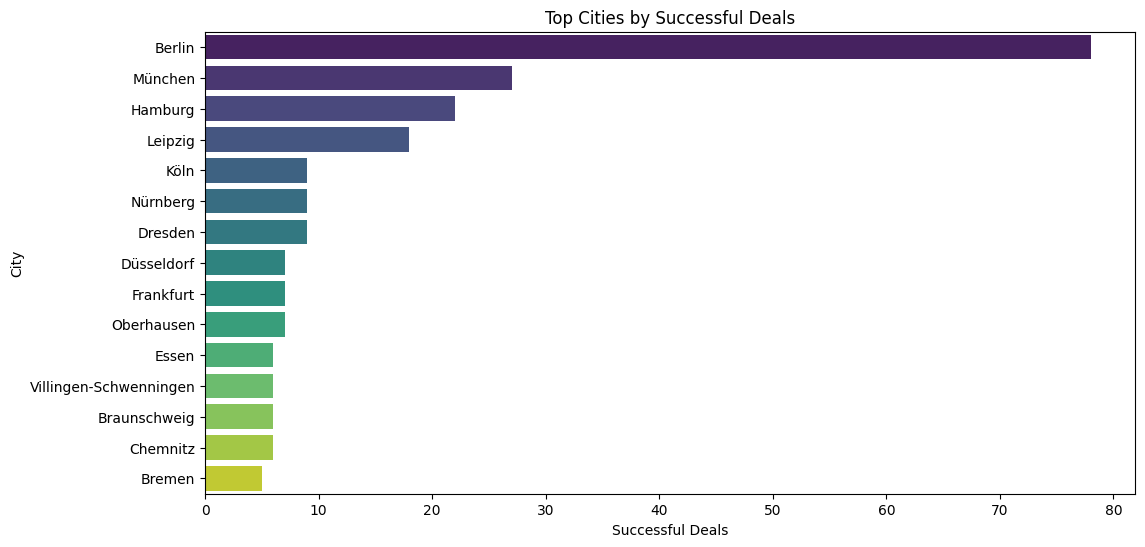

In [10]:
city_perf_clean = city_perf[
    ~city_perf["City_clean"].isin(["Unknown", "#REF!", "", None, "-"])
]

plt.figure(figsize=(12,6))
sns.barplot(
    data=city_perf_clean.head(15),
    x="Deals_won",
    y="City_clean",
    hue="City_clean",
    palette="viridis",
    legend=False
)
plt.title("Top Cities by Successful Deals")
plt.xlabel("Successful Deals")
plt.ylabel("City")
plt.show()

### 🎯 Insight
 - Berlin — main source of successful deals and revenue.

 - München, Hamburg — stable markets with high‑quality leads.

 - Leipzig — highly efficient but small market → growth opportunity.

 - Frankfurt, Köln — expensive clients but low conversion → improvement needed.

 - Düsseldorf, Dortmund — many leads but weak closing → problematic regions.

## 🔹 5. Conversion Rate by City

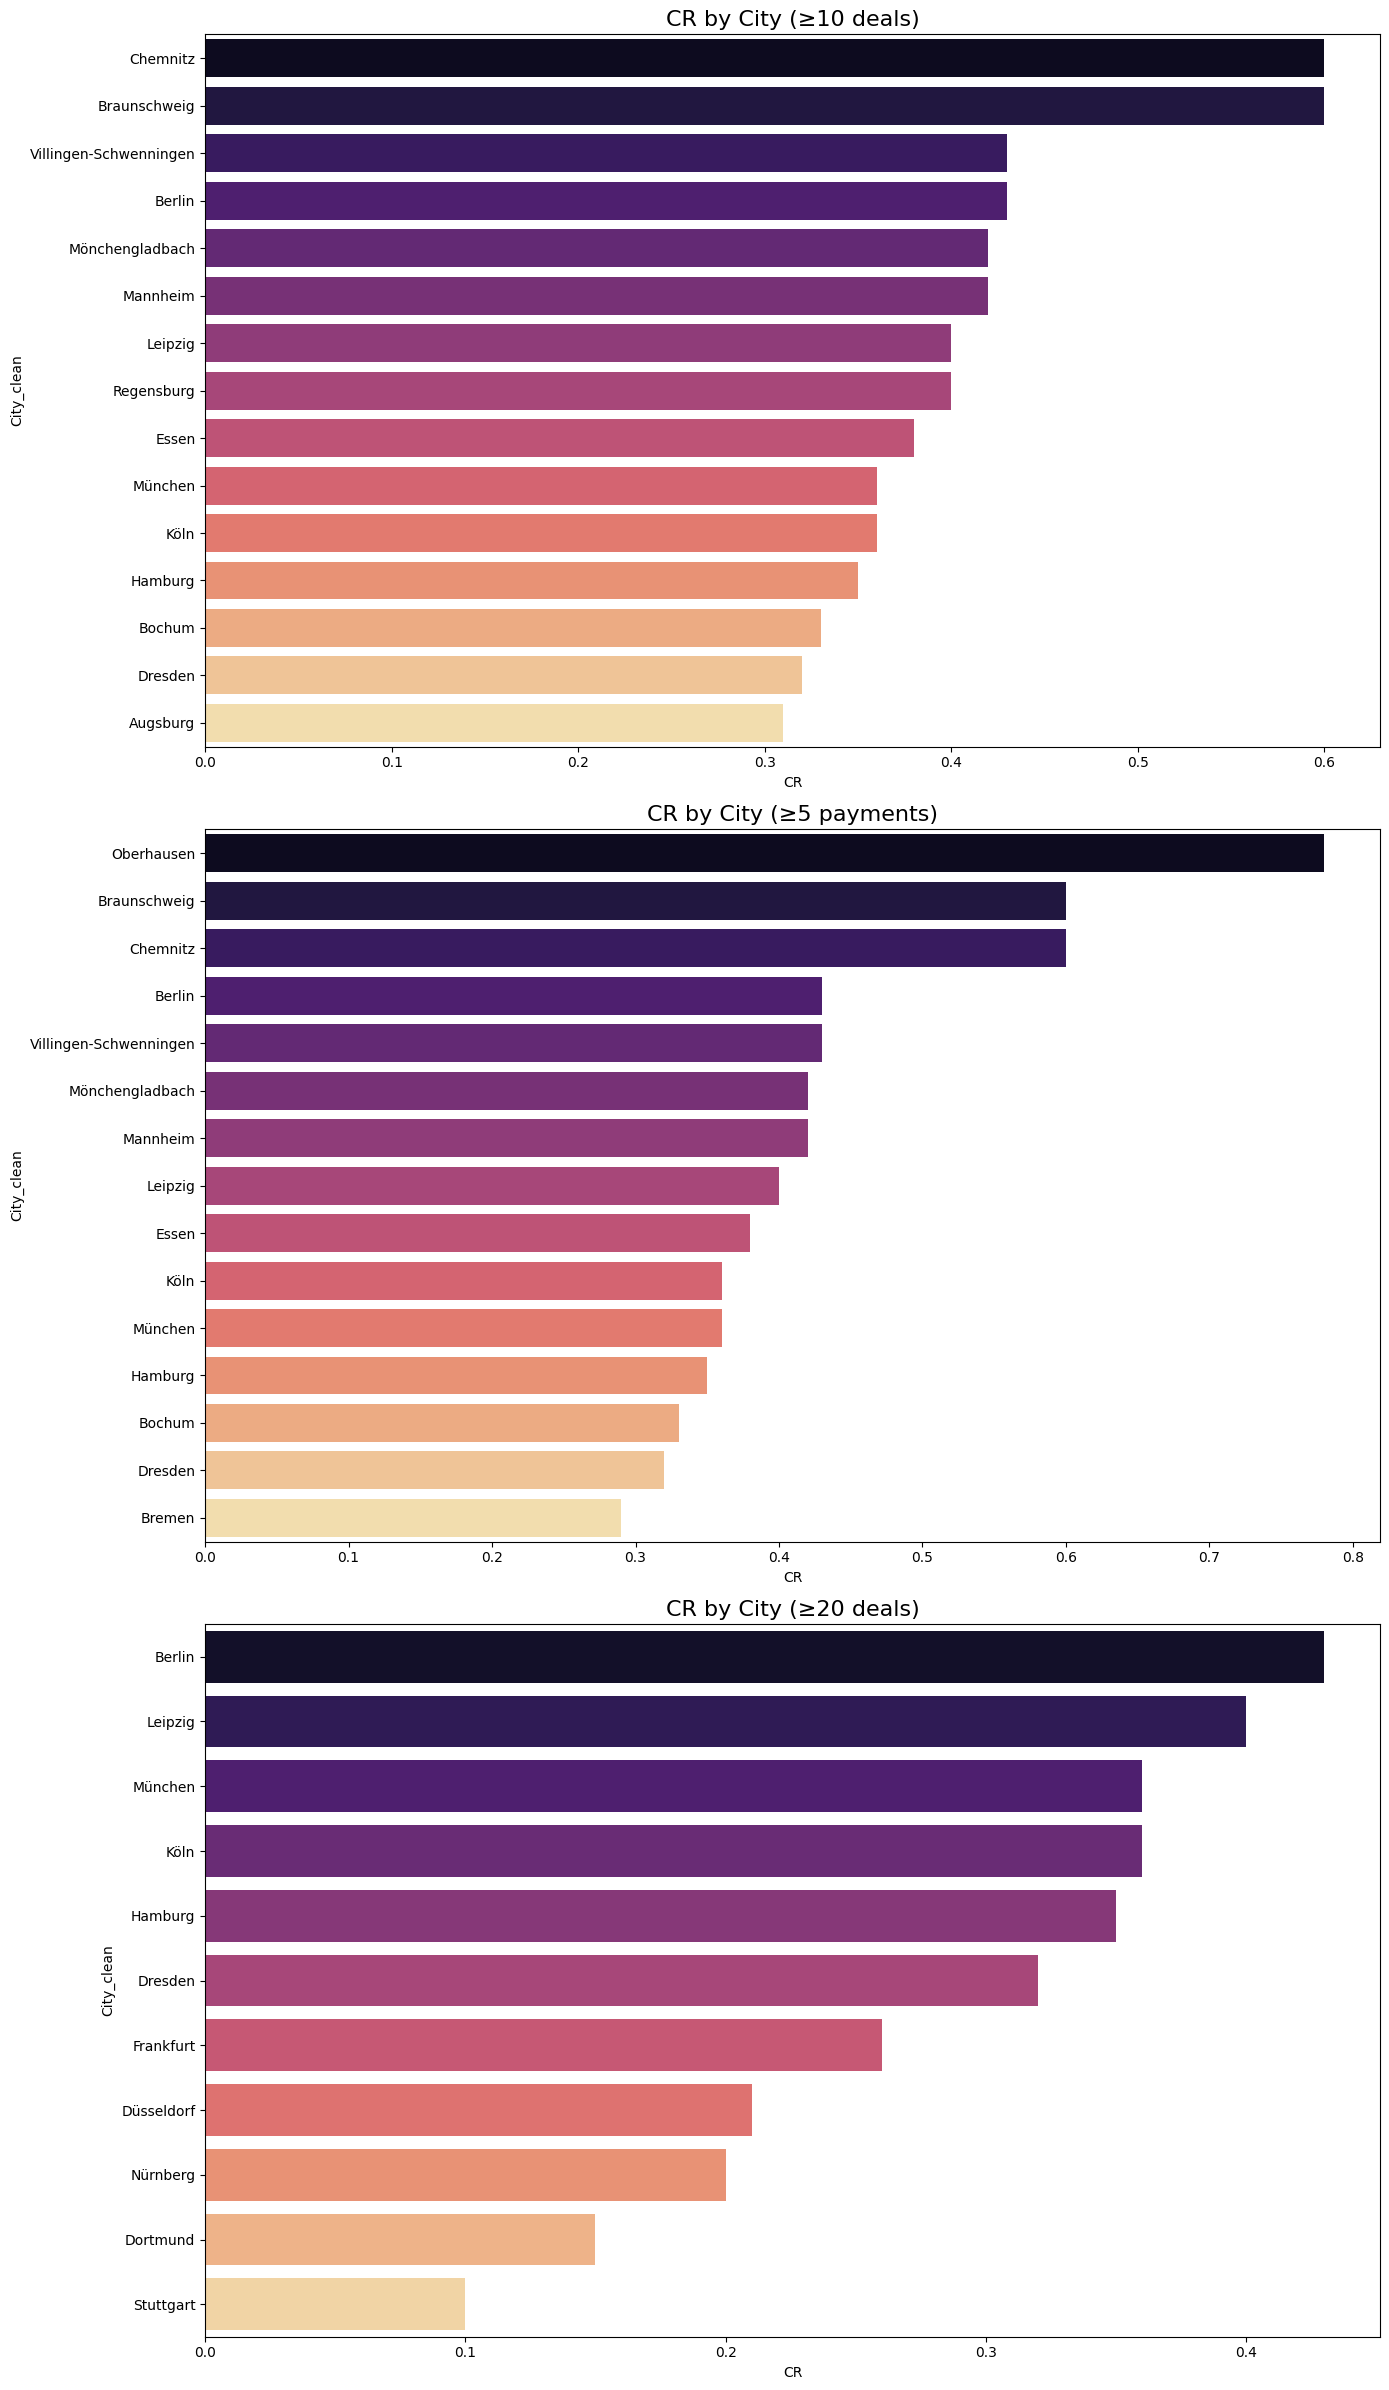

In [11]:
plt.figure(figsize=(14, 24))

# 1. ≥10 deals
plt.subplot(3, 1, 1)
df_10 = city_perf[city_perf["Deals_count"] >= 10]\
            .sort_values("CR", ascending=False).head(15)
sns.barplot(data=df_10, x="CR", y="City_clean", hue="City_clean", palette="magma", legend=False)
plt.title("CR by City (≥10 deals)", fontsize=16)

# 2. ≥5 payments
plt.subplot(3, 1, 2)
df_5won = city_perf[city_perf["Deals_won"] >= 5]\
              .sort_values("CR", ascending=False).head(15)
sns.barplot(data=df_5won, x="CR", y="City_clean", hue="City_clean", palette="magma", legend=False)
plt.title("CR by City (≥5 payments)", fontsize=16)

# 3. ≥20 deals
plt.subplot(3, 1, 3)
df_20 = city_perf[city_perf["Deals_count"] >= 20]\
             .sort_values("CR", ascending=False).head(15)
sns.barplot(data=df_20, x="CR", y="City_clean", hue="City_clean", palette="magma", legend=False)
plt.title("CR by City (≥20 deals)", fontsize=16)

plt.tight_layout()
plt.show()

### 🎯 Summary
 ✔ Filter ≥10 deals — best for analysis; shows real markets with meaningful conversion.  
 ✔ Filter ≥5 payments — shows manager efficiency; highlights where deals are closed best.  
 ✔ Filter ≥20 deals — identifies strategic markets.

## 🔹 6. Conversion by German Language Level

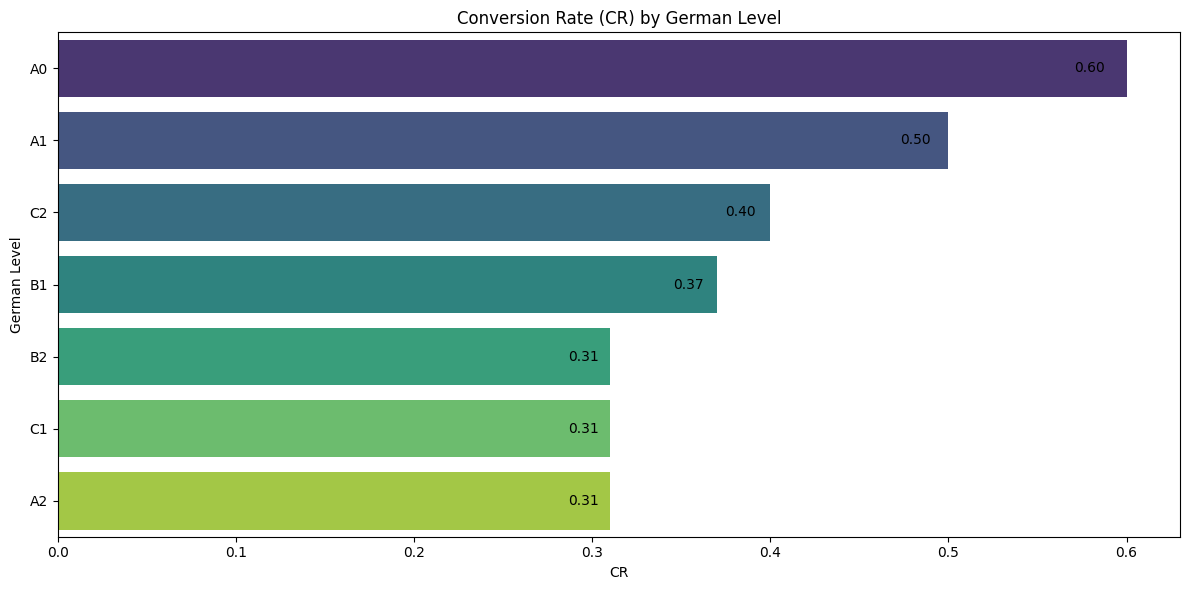

In [12]:
plt.figure(figsize=(12,6))
ax = sns.barplot(
    data=lang_perf,
    x="CR",
    y="Level of Deutsch",
    hue="Level of Deutsch",
    palette="viridis",
    dodge=False,
    legend=False
)

plt.title("Conversion Rate (CR) by German Level")
plt.xlabel("CR")
plt.ylabel("German Level")

for bar, (_, row) in zip(ax.patches, lang_perf.iterrows()):
    width = bar.get_width()
    y = bar.get_y() + bar.get_height()/2
    ax.text(width*0.98, y, f"{row['CR']:.2f}", va='center', ha='right', fontsize=10)

plt.tight_layout()
plt.show()

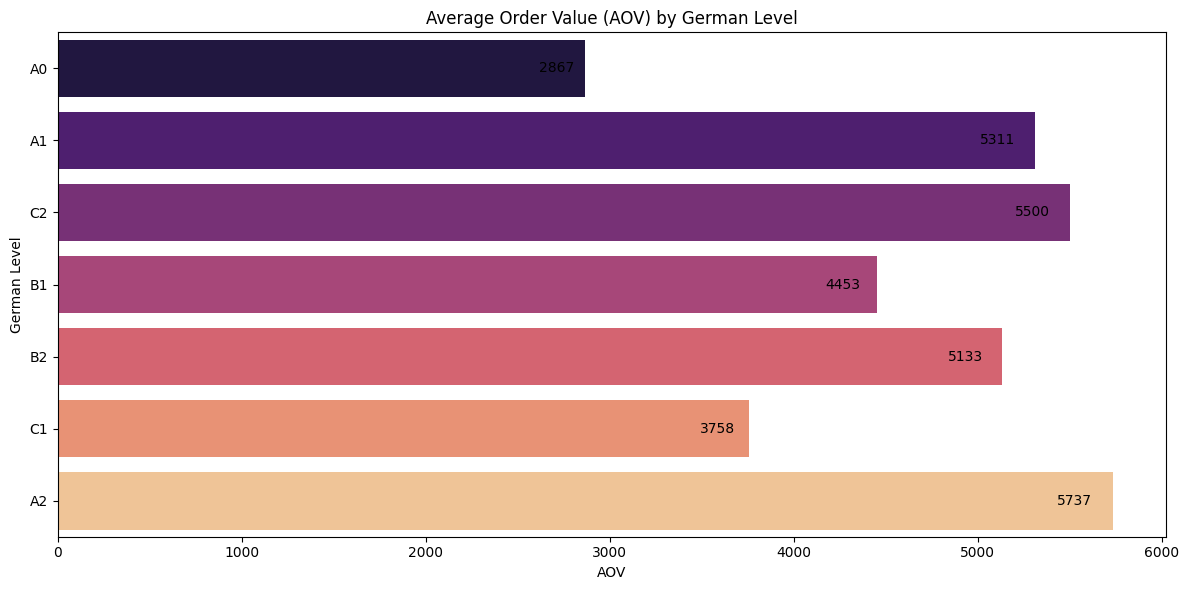

In [13]:
plt.figure(figsize=(12,6))
ax = sns.barplot(
    data=lang_perf,
    x="AOV",
    y="Level of Deutsch",
    hue="Level of Deutsch",
    palette="magma",
    dodge=False,
    legend=False
)

plt.title("Average Order Value (AOV) by German Level")
plt.xlabel("AOV")
plt.ylabel("German Level")

for bar, (_, row) in zip(ax.patches, lang_perf.iterrows()):
    width = bar.get_width()
    y = bar.get_y() + bar.get_height()/2
    ax.text(width*0.98, y, f"{row['AOV']:.0f}", va='center', ha='right', fontsize=10)

plt.tight_layout()
plt.show()

### 🎯 Summary
🔥 1. B1 — main revenue driver
Large volume + stable CR + strong AOV → primary segment for scaling.

🔥 2. B2 — high‑value clients but weaker conversion
Requires strong managers, better scripts, more trust building.

🔥 3. C1–C2 — premium clients
High CR, high AOV, but very small volume → targeted work.

🔥 4. A2 — expensive but cold
High AOV, low CR → segment for improvement.

🔥 5. A0–A1 — small but high‑quality segments
High CR, good AOV → can be strengthened.

## 🔹 7. Distribution of German Levels Among Leads

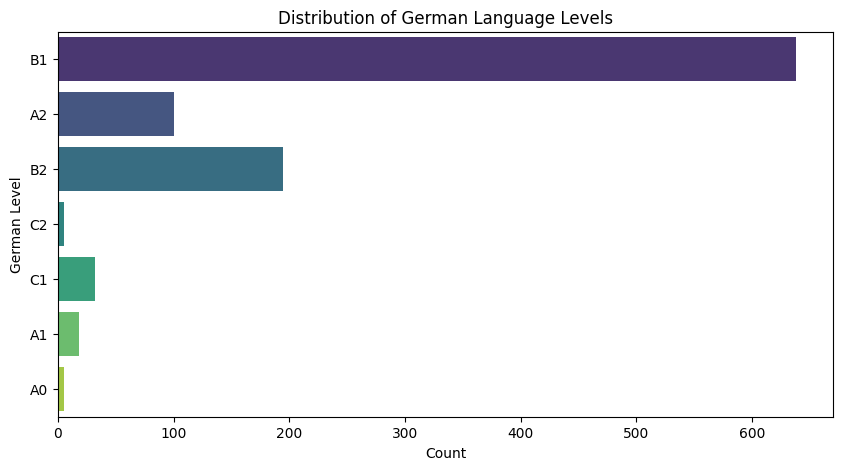

In [14]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=deals_df[deals_df["Level of Deutsch"] != "Unknown"],
    y="Level of Deutsch",
    hue="Level of Deutsch",
    palette="viridis",
    legend=False
)
plt.title("Distribution of German Language Levels")
plt.xlabel("Count")
plt.ylabel("German Level")
plt.show()

### 🎯 Summary
- B1 — key segment: large volume + strong conversion.

- B2 — second most important: smaller volume but high value.

- C1–C2 — premium clients but very few.

- A2 — weak segment, low conversion.

- Unknown — huge noisy layer → must be cleaned and validated.

## 📘 Final Conclusion
 ✔ German language level is one of the key factors influencing conversion and revenue.  
 ✔ B1 is the main working segment — generates most payments and revenue.  
 ✔ C1–C2 show high conversion but are too rare for strategic conclusions.  
 ✔ B2 is valuable but requires stronger sales work.  
 ✔ A0–A2 show low conversion — cold or unprepared audience.  
 ✔ Unknown is a massive, inefficient segment — must be cleaned, validated, and segmented.

## #️⃣ 💾 8. Saving

In [15]:
deals_df.to_excel("Deals_clean_geo.xlsx", index=False)